<a href="https://colab.research.google.com/github/wiuver/tipis/blob/main/itz4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Лабораторная работа 4. Нечёткие множества и отношения
##Часть 1. Нечёткие множества
Задача 1. Построить в Jupyter Notebook (в Visual Studio Code на Python или в Google Colab) приведенные в файле выше функции принадлежности и их графики. Вычислить значения всех функций принадлежности для х1=0,1,2,5,10.

Значения функций принадлежности:
x	μ(x)	μ1(x)	μ2(x)	μ11(x)
0	0.00	0.00	1.00	0.00
1	0.00	0.00	1.00	0.00
2	0.00	0.50	1.00	0.50
5	0.00	2.00	0.10	0.00
10	1.00	4.50	-1.40	0.00


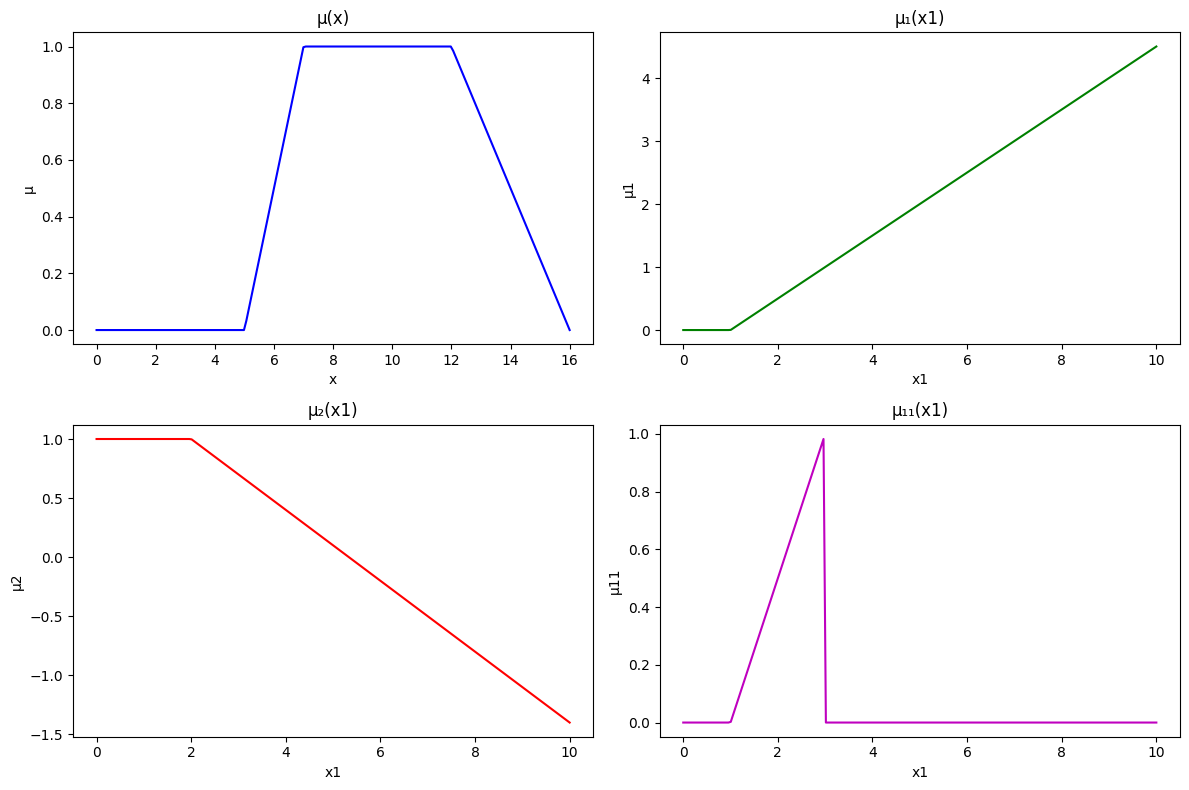

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def mu(x):
    if x < 5:
        return 0
    elif x < 7:
        return 0.5 * (x - 5)
    elif x < 12:
        return 1
    elif x < 16:
        return 1 - 0.25 * (x - 12)
    else:
        return 0

def mu1(x1):
    if x1 <= 1:
        return 0
    elif x1 <= 10:
        return 0.5 * (x1 - 1)
    else:
        return 0

def mu2(x1):
    if x1 <= 2:
        return 1
    elif x1 <= 10:
        return -0.3 * (x1 - 2) + 1
    else:
        return 0

def mu11(x1):
    val = mu1(x1)
    if val <= 1:
        return val
    else:
        return 0

x_values = [0, 1, 2, 5, 10]

print("Значения функций принадлежности:")
print("x\tμ(x)\tμ1(x)\tμ2(x)\tμ11(x)")
for x in x_values:
    print(f"{x}\t{mu(x):.2f}\t{mu1(x):.2f}\t{mu2(x):.2f}\t{mu11(x):.2f}")

x = np.linspace(0, 16, 200)
y_mu = [mu(xi) for xi in x]

x1 = np.linspace(0, 10, 200)
y_mu1 = [mu1(xi) for xi in x1]
y_mu2 = [mu2(xi) for xi in x1]
y_mu11 = [mu11(xi) for xi in x1]

plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.plot(x, y_mu, 'b')
plt.title("μ(x)")
plt.xlabel("x")
plt.ylabel("μ")

plt.subplot(2, 2, 2)
plt.plot(x1, y_mu1, 'g')
plt.title("μ₁(x1)")
plt.xlabel("x1")
plt.ylabel("μ1")

plt.subplot(2, 2, 3)
plt.plot(x1, y_mu2, 'r')
plt.title("μ₂(x1)")
plt.xlabel("x1")
plt.ylabel("μ2")

plt.subplot(2, 2, 4)
plt.plot(x1, y_mu11, 'm')
plt.title("μ₁₁(x1)")
plt.xlabel("x1")
plt.ylabel("μ11")

plt.tight_layout()
plt.show()


##Часть 2. Построение функций принадлежности на основе экспертной информации
Задание. Сформировать функции принадлежности оценок предметной области погода в регионе на основе экспертных оценок.

1. Выбрать регион - Томск(2023)
2. Получить данные по погоде в регионе из интернета для трех нечетких множеств
(температура, количество осадков, скорость ветра) за любой год.
| Температура  | Кол-во осадков |  Скорость ветра   |
|-------|-----|-------|
| -15 | 17  | 0.9 |
| -12 | 23  | 0.7 |
| -1  | 39  | 1.1 |
|  3  | 43  | 1.2 |
| 15  | 63  | 1.2 |
| 22  | 26  | 0.8 |
| 24  | 36  | 0.6 |
| 20  | 53  | 0.5 |
| 14  | 29  | 0.5 |
| 8   | 44  | 0.8 |
| -3  | 35  | 0.9 |
| -13 | 17  | 1   |

3. Исходя из типичных значений для выбранного региона разделить шкалы по
нечетким переменным на три группы
 большая (температура, осадки, скорость ветра)
 средняя (температура, осадки, скорость ветра)
 маленькая (температура, осадки, скорость ветра)
4. Сформировать группу экспертов, по своему усмотрению (не менее 3 и не более 6), и
заполнить таблицу в бинарных значениях, см пример 1.
5. Заполнить таблицу 2 с данными по обработки мнений экспертов
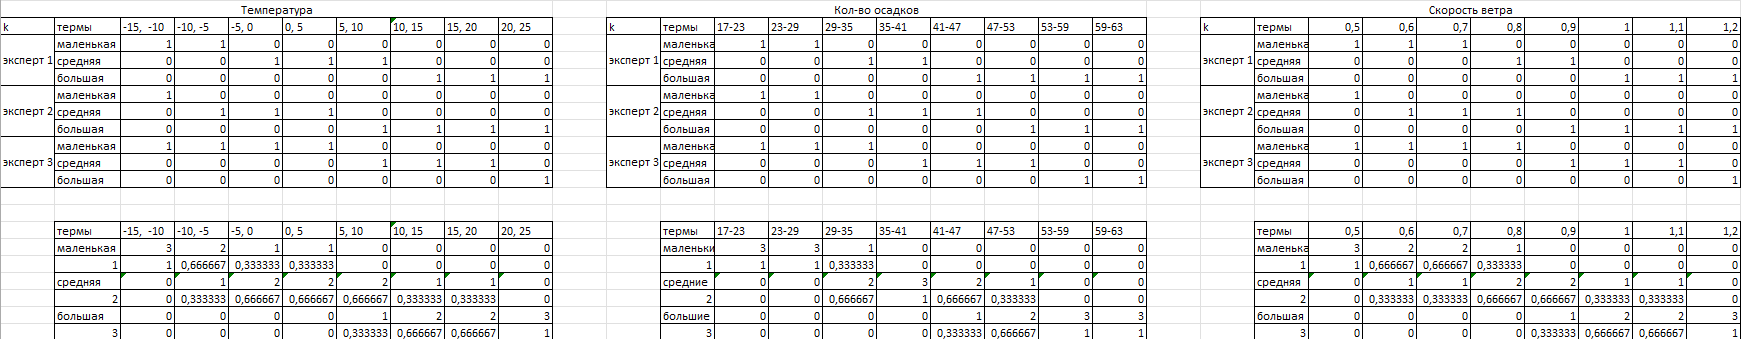
6. Сформировать функции принадлежности

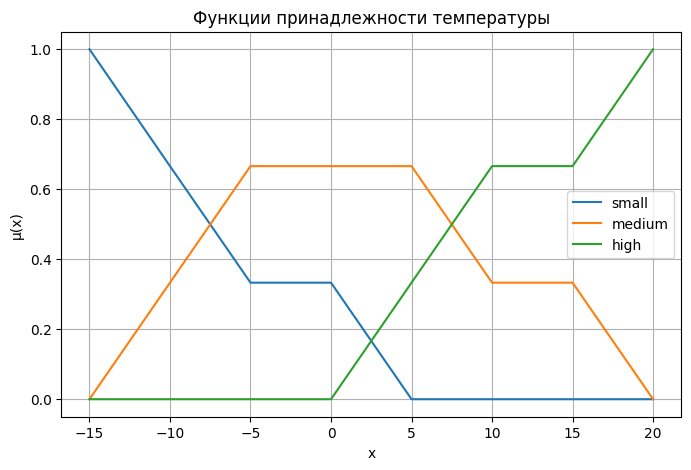

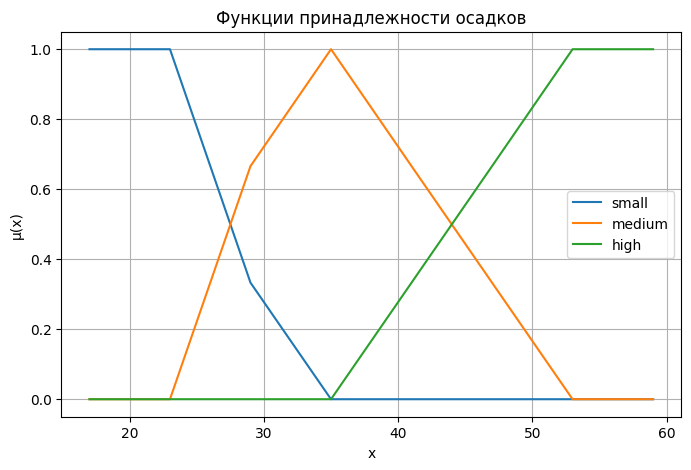

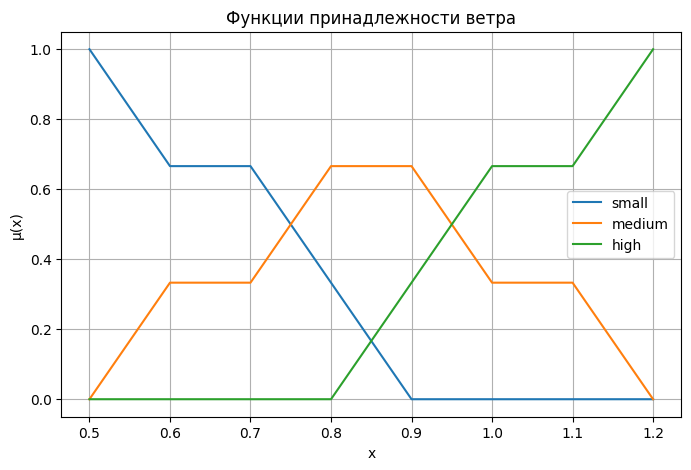

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def fff(x, fu_small, fu_medium, fu_high, a):

  # Визуализация
  plt.figure(figsize=(8, 5))
  plt.plot(x, fu_small, '-', label='small')
  plt.plot(x, fu_medium, '-', label='medium')
  plt.plot(x, fu_high, '-', label='high')
  plt.xlabel("x")
  plt.ylabel("μ(x)")
  plt.title("Функции принадлежности " + a)
  plt.legend()
  plt.grid(True)
  plt.show()
#Температура
fff(([-15, -10, -5, 0, 5, 10, 15, 20]), ([1, 0.666, 0.333, 0.333, 0, 0, 0, 0]), ([0, 0.333, 0.666, 0.666, 0.666, 0.333, 0.333, 0]), ([0, 0, 0, 0, 0.333, 0.666, 0.666, 1]), 'температуры')
#Осадки
fff(([17, 23, 29, 35, 41, 47, 53, 59]), ([1, 1, 0.333, 0, 0, 0, 0, 0]), ([0, 0, 0.666, 1, 0.666, 0.333, 0, 0]), ([0, 0, 0, 0, 0.333, 0.666, 1, 1]), 'осадков')
#Скорость ветра
fff(([0.5, 0.6, 0.7, 0.8, 0.9, 1, 1.1, 1.2]), ([1, 0.666, 0.666, 0.333, 0, 0, 0, 0]), ([0, 0.333, 0.333, 0.666, 0.666, 0.333, 0.333, 0]), ([0, 0, 0, 0, 0.333, 0.666, 0.666, 1]), 'ветра')

7. Поскольку функции принадлежности имеют негладкий вид, адекватно (т.е.
сглаживая, а не искажая) провести (кусочную) аппроксимацию полученных табличных
функций принадлежности

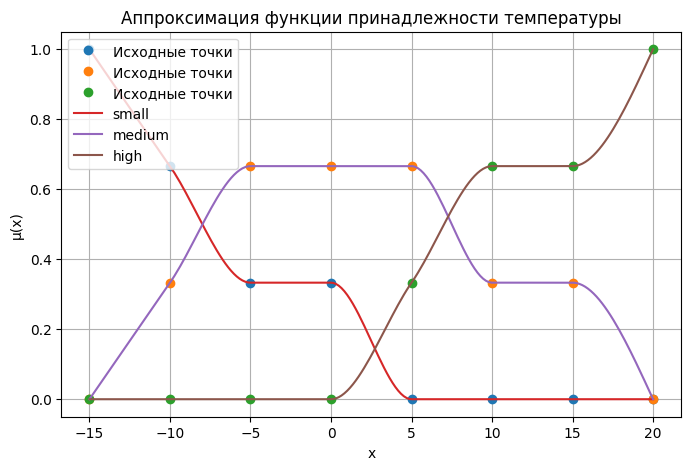

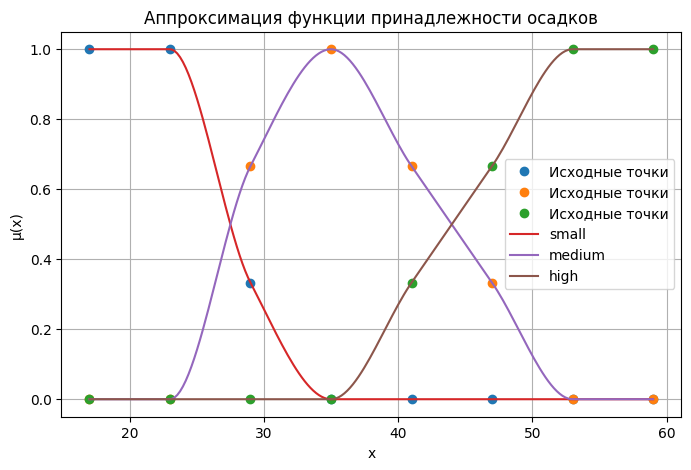

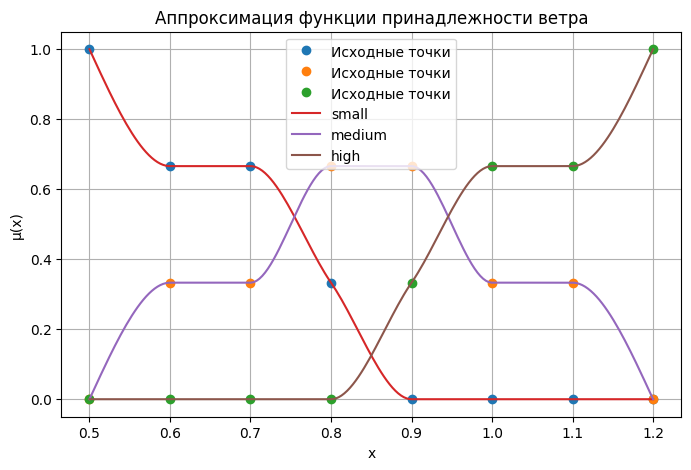

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d, CubicSpline, PchipInterpolator

def apr(x, fu_small, fu_medium, fu_high, a):

  # аппроксимация
  f_small = PchipInterpolator(x, fu_small)
  f_medium = PchipInterpolator(x, fu_medium)
  f_high = PchipInterpolator(x, fu_high)

  # сетка для графика
  x_new = np.linspace(min(x), max(x), 200)
  fn_small = f_small(x_new)
  fn_medium = f_medium(x_new)
  fn_high = f_high(x_new)

  # Визуализация
  plt.figure(figsize=(8, 5))
  plt.plot(x, fu_small, 'o', label='Исходные точки')
  plt.plot(x, fu_medium, 'o', label='Исходные точки')
  plt.plot(x, fu_high, 'o', label='Исходные точки')
  plt.plot(x_new, fn_small, '-', label='small')
  plt.plot(x_new, fn_medium, '-', label='medium')
  plt.plot(x_new, fn_high, '-', label='high')
  plt.xlabel("x")
  plt.ylabel("μ(x)")
  plt.title("Аппроксимация функции принадлежности " + a)
  plt.legend()
  plt.grid(True)
  plt.show()
#Температура
apr(([-15, -10, -5, 0, 5, 10, 15, 20]), ([1, 0.666, 0.333, 0.333, 0, 0, 0, 0]), ([0, 0.333, 0.666, 0.666, 0.666, 0.333, 0.333, 0]), ([0, 0, 0, 0, 0.333, 0.666, 0.666, 1]), 'температуры')
#Осадки
apr(([17, 23, 29, 35, 41, 47, 53, 59]), ([1, 1, 0.333, 0, 0, 0, 0, 0]), ([0, 0, 0.666, 1, 0.666, 0.333, 0, 0]), ([0, 0, 0, 0, 0.333, 0.666, 1, 1]), 'осадков')
#Скорость ветра
apr(([0.5, 0.6, 0.7, 0.8, 0.9, 1, 1.1, 1.2]), ([1, 0.666, 0.666, 0.333, 0, 0, 0, 0]), ([0, 0.333, 0.333, 0.666, 0.666, 0.333, 0.333, 0]), ([0, 0, 0, 0, 0.333, 0.666, 0.666, 1]), 'ветра')

##Часть 3. Операции над нечёткими множествами. Нечёткий логический вывод
1. Дано множество U = {1, 2, 3, 4}. Определить: A ∪ B, A ⋂ B, ~A, ~B , CON(A), CON(B), ~CON(A), DIL(A), DIL(B).

| x   | A     | B     | A ∪ B | A ⋂ B | ~A    | ~B    |
| --: | --:   | --:   | --:   | --:    | --:   | --:   |
|  1  |   1   |   0   |  1    |    0   |   0   |   1   |
|  2  |   0.8 |   0.1 |  0.8  |    0.1 |   0.2 |   0.9 |
|  3  |   0.4 |   0.7 |  0.7  |    0.4 |   0.6 |   0.3 |
|  4  |   0   |   1   |  1    |    0   |   1   |    0  |

---

| x   | CON(A) | CON(B) | ~CON(A) | DIL(A)  | DIL(B) |
| --: | --:    | --:    | --:     | --:     | --:    |
|  1  |   1    |   0    |  0      |    1    |   0    |
|  2  |  0.64  |   0.01 |  0.36   |    0.894|   0.316|
|  3  |  0.16  |   0.49 |  0.84   |    0.632|   0.837|
|  4  |   0    |   1    |  1      |    0    |   1    |


2. Построить нечеткое отношение S из V в W (по вариантам)

Определены следующие правила:

если u – очень маленькое, то v – не большое,

маленькое = 1/1 + 0.8/2 + 0.4/3 + 0/4,

большое = 0/1 + 0.1/2 + 0.7/3 + 1/4


S(u,v)=max(1-Ом(u),1-μбольш​(v)),

S1​(u,v)=max(1−CON(u),1−μбольш​(v)),

| u\v |  1  |   2  |   3  |   4  |
| :-: | :-: | :--: | :--: | :--: |
|  1  | 1   |  0.9 |  0.3 |  0   |
|  2  | 1   |  0.9 |  0.36| 0.36 |
|  3  | 1   |  0.9 |  0.84| 0.84 |
|  4  | 1   |  1   |  1   |  1   |
